**Ciencia de datos 12-13 hrs.**

**Docente:** Zuriel Dathan Mora Felix

**Alumnos:** Bejarano Felix Bernardo Daniel, de la Mora Morales Ricardo

**Archivo analizado:** `datos_estacion_25015_2025.csv`

---

# Índice

1. [Análisis estadístico descriptivo](#analisis-estadistico-descriptivo)
2. [Construcción de gráficas](#construccion-de-graficas)

    A. [Histograma](#histograma)
    
    B. [Diagrama de densidad](#diagrama-de-densidad)
    
    C. [Boxplot](#boxplot)
3. [Análisis de tendencias temporal](#analisis-de-tendencias-temporal)
4. [Comentarios y conclusiones](#comentarios-y-conclusiones)

# Análisis estadístico de datos meteorológicos 2025

Este notebook analiza el archivo `datos_estacion_25015_2025.csv` con estadística descriptiva, detección de valores atípicos, histogramas, densidad, boxplots y análisis temporal.

Variables analizadas: `Precip`, `Evap`, `Tmax` y `Tmin`.

Sensor CONAGUA: `CULIACAN (DGE) - 25015`

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Cargamos el dataset y realizamos un análisis exploratorio inicial 
# para entender su estructura, tipos de datos, valores faltantes, etc.
df = pd.read_csv("datos_estacion_25015_2025.csv")
df["Fecha"] = pd.to_datetime(df["Fecha"])
df = df.sort_values("Fecha").reset_index(drop=True)

# Identificamos las columnas numéricas y la columna temporal para un análisis más detallado.
numericas = df.select_dtypes(include="number").columns.tolist()
temporal = "Fecha"


print(f"Filas: {df.shape[0]}, columnas: {df.shape[1]}")
print(f"Rango temporal: {df[temporal].min().date()} a {df[temporal].max().date()}")
print(f"Variables numéricas: {numericas}")

Filas: 365, columnas: 5
Rango temporal: 2025-01-01 a 2025-12-31
Variables numéricas: ['Precip', 'Evap', 'Tmax', 'Tmin']


<a id="analisis-estadistico-descriptivo"></a>
## 1. Análisis estadístico descriptivo


In [23]:
# Realizamos un análisis exploratorio inicial para entender 
# la estructura del dataset, tipos de datos, valores faltantes, etc.
print(df.head())
print(df.dtypes.to_frame("tipo"))
print(df.isna().sum().to_frame("faltantes"))

       Fecha  Precip  Evap  Tmax  Tmin
0 2025-01-01     0.0  1.08  29.5  11.0
1 2025-01-02     0.0  1.40  31.0  12.0
2 2025-01-03     0.0  0.97  30.0  13.0
3 2025-01-04     0.0  1.37  30.0  14.0
4 2025-01-05     0.0  1.67  30.0  13.0
                  tipo
Fecha   datetime64[us]
Precip         float64
Evap           float64
Tmax           float64
Tmin           float64
        faltantes
Fecha           0
Precip          0
Evap           52
Tmax            0
Tmin            0


In [24]:
# Rellenamos lo valores nulos de cada columna numérica con 
# el promedio de esa columna, segun lo visto en clase.
columnas_con_nulos = df.columns[df.isna().any()].tolist()
for col in columnas_con_nulos:
    promedio = df[col].mean()
    df[col] = df[col].fillna(promedio)

print(df.isna().sum().to_frame("faltantes"))

        faltantes
Fecha           0
Precip          0
Evap            0
Tmax            0
Tmin            0


In [25]:
# Calculamos un resumen estadístico para cada variable numérica, 
# incluyendo medidas de tendencia central, dispersión y percentiles.
def resumen_estadistico(serie: pd.Series) -> pd.Series:
    datos = serie.dropna()
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    moda = datos.mode()
    return pd.Series({
        "media": datos.mean(),
        "mediana": datos.median(),
        "moda": ", ".join(map(str, moda.tolist())) if len(moda) else "Sin moda",
        "minimo": datos.min(),
        "maximo": datos.max(),
        "rango": datos.max() - datos.min(),
        "varianza": datos.var(),
        "desviacion_std": datos.std(),
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
    })

columnas_numericas = ['Precip', 'Evap', 'Tmax', 'Tmin']
tabla_descriptiva = df[columnas_numericas].apply(resumen_estadistico)

print(tabla_descriptiva)

                   Precip              Evap       Tmax       Tmin
media            1.602521          4.711821  34.728767  19.923288
mediana               0.0          4.711821       35.5       20.0
moda                  0.0  4.71182108626198       36.0       24.0
minimo                0.0               0.3       20.0        8.0
maximo               62.5             19.25       41.5       29.0
rango                62.5             18.95       21.5       21.0
varianza        44.294436          6.842713  12.404253  28.227616
desviacion_std   6.655407          2.615858   3.521967   5.312967
q1                    0.0              2.72       33.0       15.0
q3                    0.0              5.99       37.0       25.0
iqr                   0.0              3.27        4.0       10.0


##### **Explicar qué indica la desviación estándar sobre la dispersión de los datos.**

La desviación estándar indica qué tanto se alejan los registros del promedio general.
En la tabla anterior, las temperaturas (Tmax = 3.53, Tmin = 5.31) tienen una desviación baja, podemos deducir que el clima es estable y los valores se concentran cerca de la media. Por el contrario, la precipitación (Precip = 6.65) tiene una desviación mayor en comparación con su media (1.60), lo que refleja una gran dispersión: hay muchísimos días sin lluvia y unos pocos días con lluvias extremas.

##### **Comparar la media con la mediana e inferir si existe sesgo en la distribución.**

Distribución simétrica: En Evap (Media 4.71 vs Mediana 4.71), Tmax (Media 34.72 vs Mediana 35.5), Tmin (Media 19.92 vs Mediana 20.0) los valores son prácticamente idénticos. Esto indica que no hay sesgo y los datos se distribuyen uniformemente (forma de campana).

Sesgo a la derecha (Positivo): En la variable Precip, la media (1.60) es notablemente mayor que la mediana (0.0). Esto confirma un fuerte sesgo a la derecha, lo que significa que la mayoría de los datos se acumulan en el cero, pero una cola de valores altos jala el promedio hacia arriba.

In [26]:
# Calculamos outliers utilizando la regla del IQR para cada variable numérica 
# y resumimos los resultados en un DataFrame.
def outliers_iqr(df_local: pd.DataFrame, columna: str) -> pd.DataFrame:
    datos = df_local[columna].dropna()
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    mascara = (df_local[columna] < limite_inferior) | (df_local[columna] > limite_superior)
    df_atipicos = df_local.loc[mascara, ["Fecha", columna]].copy()

    estadisticas = {
        "variable": columna,
        "outliers": len(df_atipicos),
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior
    }

    return df_atipicos, estadisticas

# Calculamos outliers utilizando la regla del IQR para cada variable numérica 
# y resumimos los resultados en un DataFrame.
outlier_resumen = []
for col in numericas:
    # Llama a la funcion y desempaqueta los dos resultados
    outliers_data, resumen_stats = outliers_iqr(df, col)
    
    # Agrega el diccionario directamente a la lista final
    outlier_resumen.append(resumen_stats)

# Mostramos el resumen de outliers para cada variable numérica.
display(pd.DataFrame(outlier_resumen))

,variable,outliers,limite_inferior,limite_superior
0,Precip,69,0.000,0.000
1,Evap,7,-2.185,10.895
2,Tmax,8,27.000,43.000
3,Tmin,0,0.000,40.000


##### **Identificar valores atípicos (outliers), si los hay, y explicar su posible impacto.**

Mediante el análisis del Rango Intercuartílico (IQR), se identificaron valores atípicos únicamente en las variables de precipitación (69 días) y evaporación (7 día). Las temperaturas máximas y mínimas registraron 0 valores atípicos, lo que demuestra que el comportamiento térmico es muy estable y predecible a lo largo del año, sin anomalías extremas.

En el caso particular de la precipitación, los límites matemáticos inferior y superior son de 0.0. Esto ocurre porque durante más del 75% del año no llueve, haciendo que los cuartiles sean cero. En consecuencia, cualquier día que presente lluvia es clasificado estadísticamente como un evento atípico, lo cual estadísiticamente es anomalia, pero es un comportamiento normal de la lluvia. 


<a id="construccion-de-graficas"></a>
## 2. Construcción de gráficas


<a id="histograma"></a>
### A) Histograma

##### **Mostrar la distribución de los datos.**

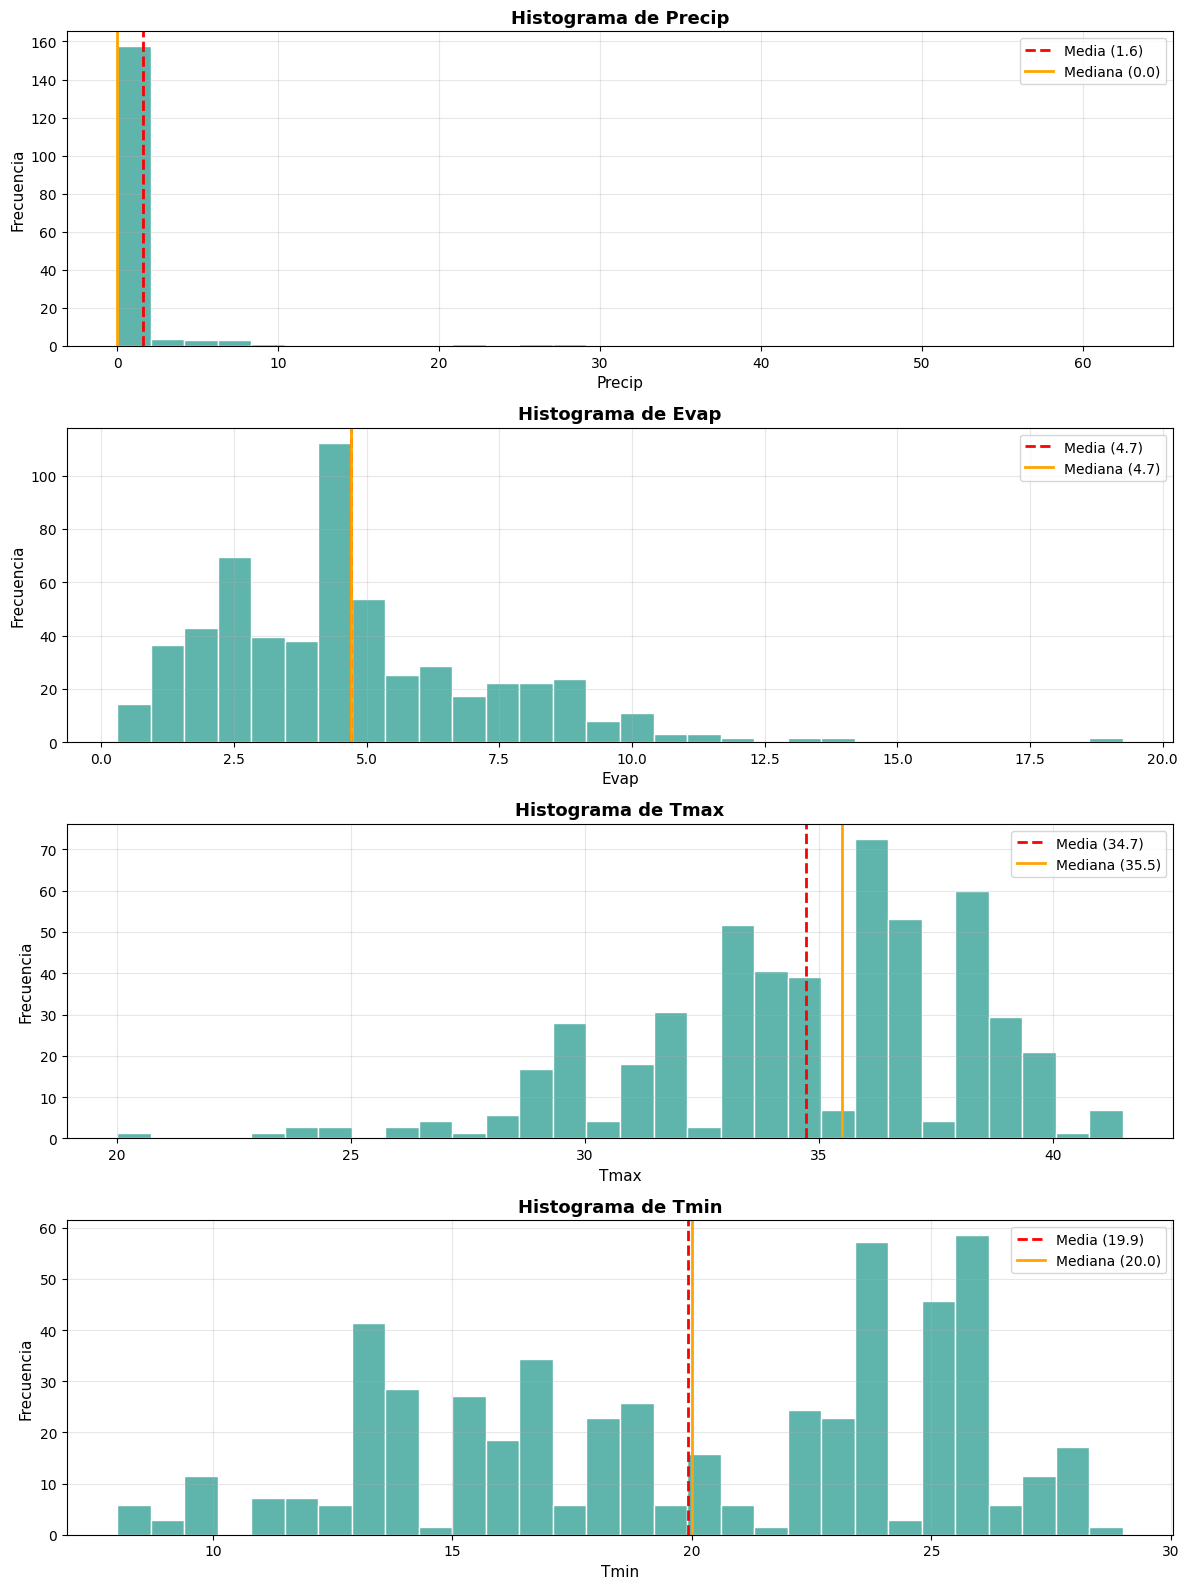

In [27]:
fig, axes = plt.subplots(len(numericas), 1, figsize=(12, 4 * len(numericas)))

for fila, col in enumerate(numericas):
    serie = df[col].dropna()
    media = serie.mean()
    mediana = serie.median()
    
    ax_hist = axes[fila] if len(numericas) > 1 else axes
    
    sns.histplot(serie, bins=30, ax=ax_hist, color="#2a9d8f", edgecolor="white", stat="frequency")
    
    ax_hist.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media ({media:.1f})')
    ax_hist.axvline(mediana, color='orange', linestyle='-', linewidth=2, label=f'Mediana ({mediana:.1f})')
    
    ax_hist.set_title(f"Histograma de {col}", fontsize=13, fontweight="bold")
    ax_hist.set_xlabel(col, fontsize=11)
    ax_hist.set_ylabel("Frecuencia", fontsize=11)
    
    ax_hist.legend(fontsize=10)
    ax_hist.grid(True, alpha=0.3)

# Ajusta el espaciado y renderiza la grafica
plt.tight_layout()
plt.show()

##### **Analizar la forma de la distribución (simétrica, sesgada a la izquierda/derecha, multimodal).**

**Variable PRECIP** 
Se ve una distribución sesgada a la derecha esto ya que la mayoría de días del año no se presentaron lluvias.
**Variable EVAP** 
Se ve una distribución sesgada a la derecha, el que haya días de alta evaporacion (outliers) contribuye al aumento de las temperaturas.
**Variable TMAX** 
Se ve una distribución con algunos puntos bajos intemedios y sesgada a la izquierda, la campana esta inclinada a la derecha lo que supone que la mayor parte del año hay temperaturas altas en la región.
**Variable TMIN** 
Se ve una distribución bimodal conentrandoce la media y mediana en el valle (anticima), esto indica que por lo general la TMIN era un poco mayor o menor que la media en la mayoria de los días del año.

##### **Relacionar la forma del histograma con las medidas estadísticas obtenidas.**

Cuando la media y la mediana están muy separadas, como en `Precip`, el histograma se sesga.
Cuando ambas son cercanas, como en `Evap` y `Tmin`, la distribución es más equilibrada.
La presencia de colas largas en `Precip` y `Tmax` explica la existencia de valores atípicos y una desviación estándar más sensible a extremos.


<a id="diagrama-de-densidad"></a>
### B) Diagrama de densidad

##### **Comparar visualmente la densidad de los datos.**

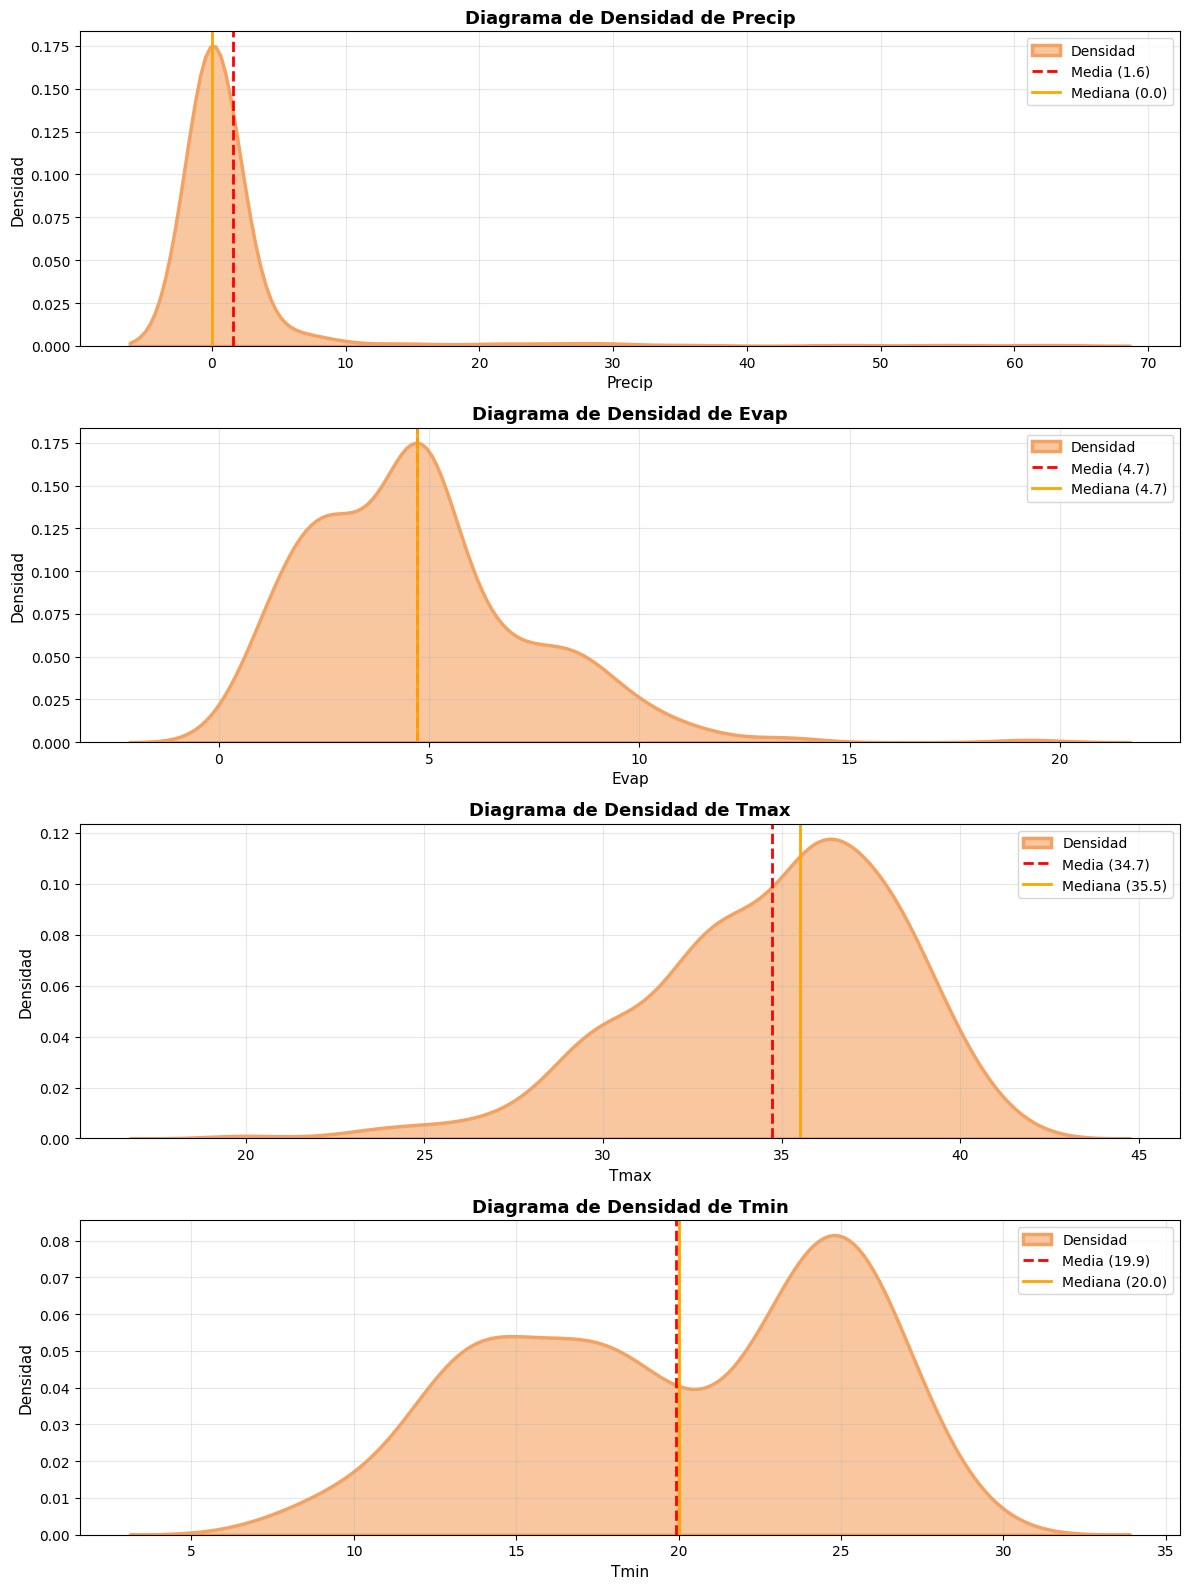

In [28]:
fig, axes = plt.subplots(len(numericas), 1, figsize=(12, 4 * len(numericas)))

for fila, col in enumerate(numericas):
    serie = df[col].dropna()
    media = serie.mean()
    mediana = serie.median()
    
    ax_den = axes[fila] if len(numericas) > 1 else axes
    
    sns.kdeplot(serie, ax=ax_den, fill=True, color="#f4a261", linewidth=2.5, alpha=0.6, label="Densidad")
    
    ax_den.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media ({media:.1f})')
    ax_den.axvline(mediana, color='orange', linestyle='-', linewidth=2, label=f'Mediana ({mediana:.1f})')
    
    ax_den.set_title(f"Diagrama de Densidad de {col}", fontsize=13, fontweight="bold")
    ax_den.set_xlabel(col, fontsize=11)
    ax_den.set_ylabel("Densidad", fontsize=11)
    
    ax_den.legend(fontsize=10)
    ax_den.grid(True, alpha=0.3)

# Ajusta el espaciado y renderiza la grafica
plt.tight_layout()
plt.show()

##### **Analizar la concentración de valores y dispersión.**

El analisís de diagrama de densidad solo confirma lo que ya observamos en el histograma, pero vale la pena recalcar que aclara un poco más la información, como lo es el caso de TMIN, donde nos permite visualizar que la temperatura generalmente suele estar entre los 15 o 25 grados, algo que mencionamos en el analísis del histograma pero sin tener los valores aproximados de esas dos temperaturas.

##### **Explicar similitudes o diferencias respecto al histograma.**

En este caso el diagrama de densidad tiene una arquitectura muy similar al histograma solo que mostrando mayor fluidez con los datos, donde podemos notar una pequeña diferencia es el el diagrama de densidad de TMAX, ya que al ser una linea curva fluida no se logra a preciar a gran detalle esos picos bajos de la campana que en el histograma si pueden visualizarse con fácilidad. 

<a id="boxplot"></a>
### C) Boxplot

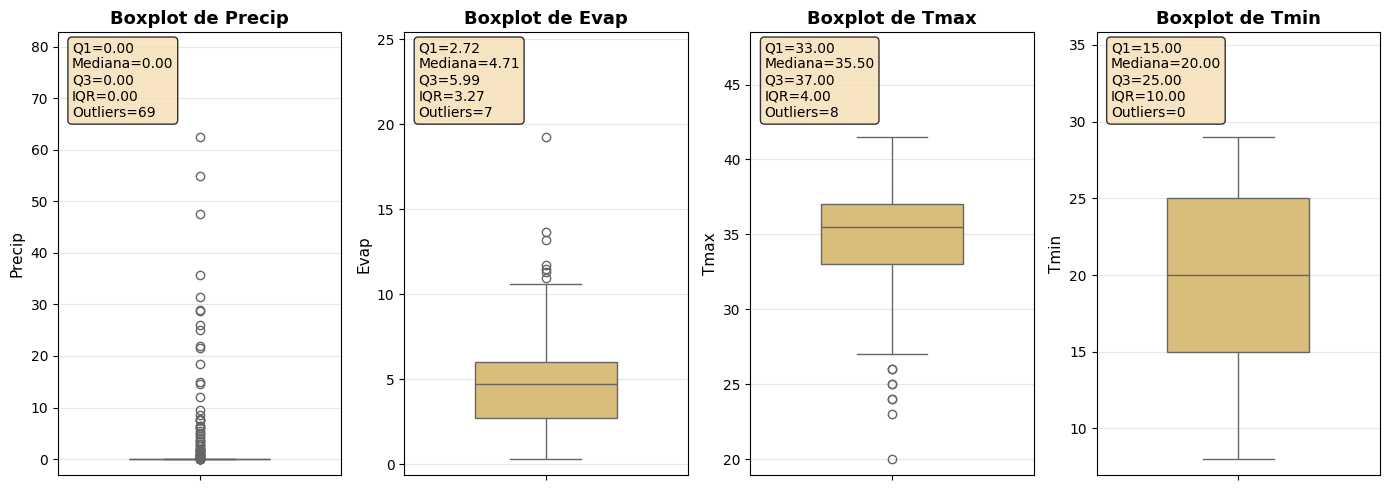

In [29]:
fig, axes = plt.subplots(1, len(columnas_numericas), figsize=(14, 5))

for col_idx, col in enumerate(columnas_numericas):
    serie = df[col].dropna()
    
    ax_box = axes[col_idx] if len(columnas_numericas) > 1 else axes
    
    sns.boxplot(y=serie, ax=ax_box, color="#e9c46a", width=0.5)
    
    q1 = serie.quantile(0.25)
    mediana = serie.median()
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    min_val = serie.min()
    max_val = serie.max()
    
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    n_outliers = ((serie < limite_inferior) | (serie > limite_superior)).sum()
    
    y_min, y_max = ax_box.get_ylim()
    ax_box.set_ylim(y_min, y_max + (y_max - y_min) * 0.25) # Agrega 25% de espacio extra arriba
    
    ax_box.set_title(f"Boxplot de {col}", fontsize=13, fontweight="bold")
    ax_box.set_ylabel(col, fontsize=11)
    ax_box.grid(True, alpha=0.3, axis="y")
    
    textstr = f"Q1={q1:.2f}\nMediana={mediana:.2f}\nQ3={q3:.2f}\nIQR={iqr:.2f}\nOutliers={n_outliers}"
    ax_box.text(0.05, 0.98, textstr, transform=ax_box.transAxes, fontsize=10,
                verticalalignment='top', horizontalalignment='left', 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

#### **Identificar la mediana, cuartiles y rango intercuartílico (IQR).**

Los gráficos exponen numéricamente y visualmente la distribución central de los datos (el 50% central representado por la caja). Por ejemplo, en la temperatura máxima (Tmax), la mediana se ubica en 35.5, con una caja estrecha (IQR de 4.0) lo que indica poca variabilidad en los días cálidos. En cambio, la precipitación muestra una caja comprimida en el cero, indicando que la mayoría de los días no llovió en absoluto.

#### **Detectar valores atípicos.**

El gráfico revela que las temperaturas son variables estables (Tmin no tiene outliers), pero existen eventos climáticos inusuales. Estos se visualizan claramente como circulos individuales fuera de los bigotes: 69 días de lluvias extremas en Precip (que rompen el límite superior matemático), 8 días de temperaturas máximas atípicas (olas de frío) y 7 días de alta evaporación (mucha humedad).

#### **Evaluar la dispersión y el posible sesgo de los datos.**

La asimetría de las cajas confirma el sesgo. En Tmin, la línea de la mediana divide la caja amarilla exactamente por la mitad, lo que confirma una distribución simétrica. Sin embargo, en Tmax y Evap, la mediana no se encuentra en el centro y los bigotes son desiguales, lo que confirma de manera visual el fuerte sesgo (asimetría) que previamente indicaban el histograma y la diferencia entre media y mediana.
Por la naturaleza de la variable Precip no se pueden observar sus cajas.

<a id="analisis-de-tendencias-temporal"></a>
## 3. Análisis de tendencias temporal

#### **Construir una gráfica de línea.**

,Precip,Evap,Tmax,Tmin
Fecha,,,,
2025-01-31,0.18,2.27,28.32,11.87
2025-02-28,0.00,3.51,32.48,12.75
2025-03-31,0.00,5.30,33.84,13.76
2025-04-30,0.00,6.83,35.60,17.82
2025-05-31,0.06,8.28,37.95,20.61
2025-06-30,0.78,6.52,38.28,26.20
2025-07-31,6.29,5.99,37.02,25.18
2025-08-31,5.45,4.59,36.76,25.10
2025-09-30,5.84,5.17,35.55,25.05


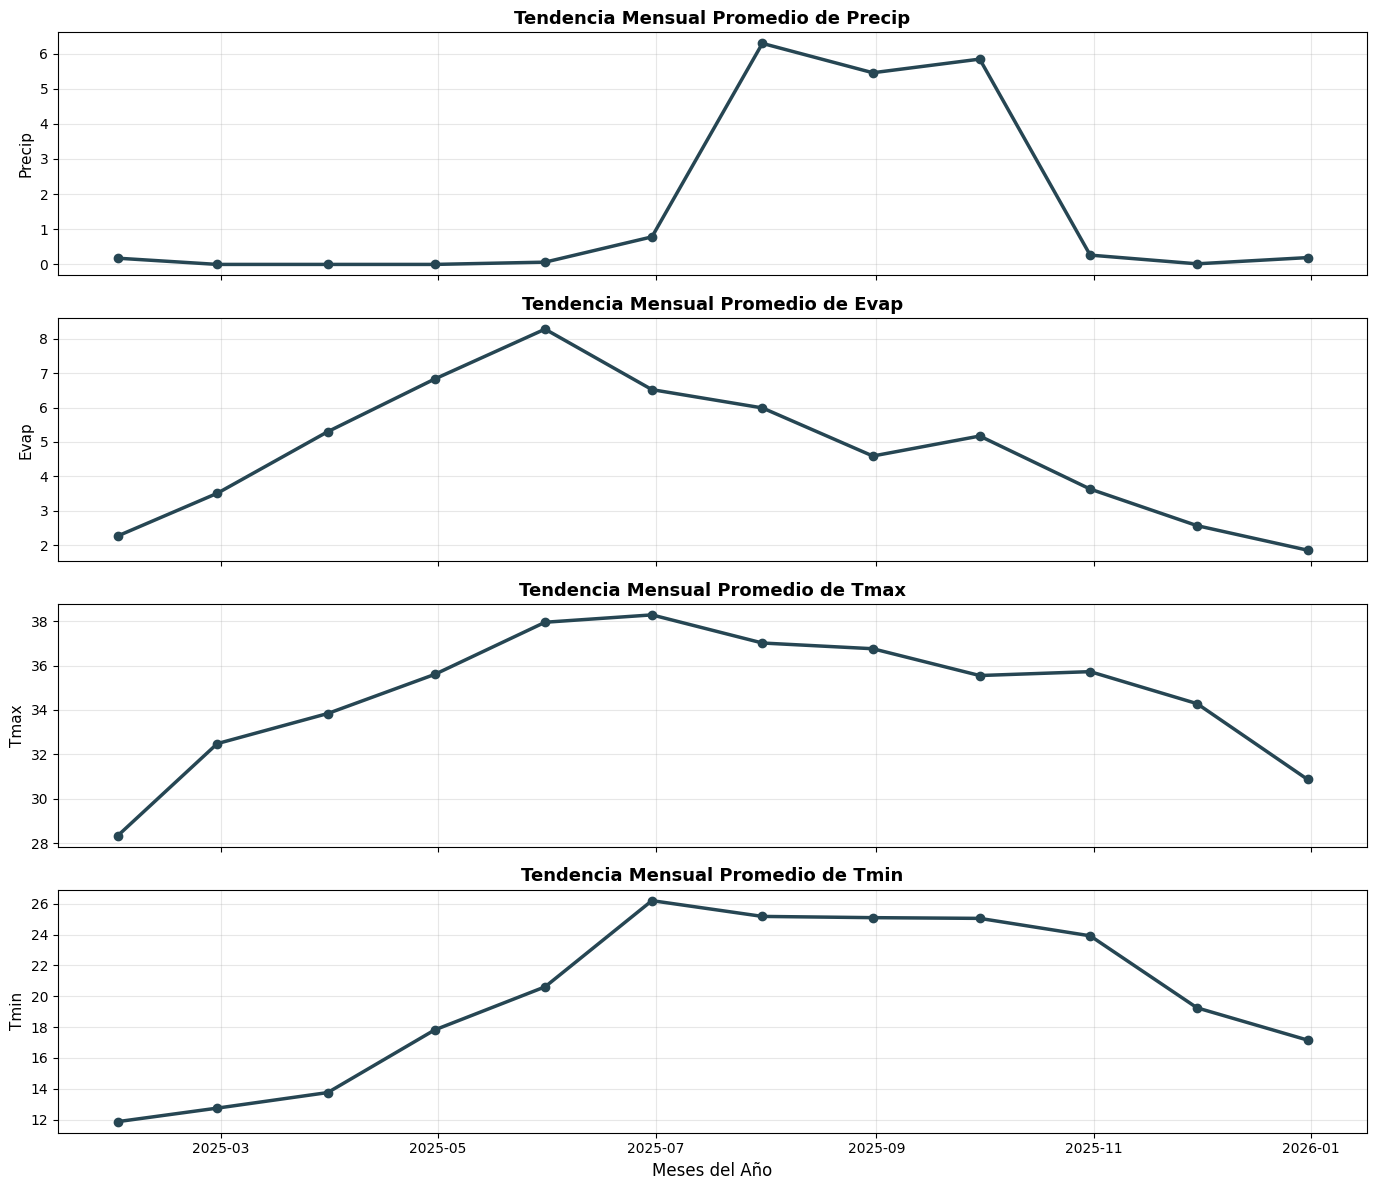

In [30]:
mensual = df.set_index("Fecha")[columnas_numericas].resample("ME").mean()
display(mensual.round(2))

fig, axes = plt.subplots(len(columnas_numericas), 1, figsize=(14, 12), sharex=True)

for ax, col in zip(axes, columnas_numericas):
    ax.plot(mensual.index, mensual[col], marker="o", linewidth=2.5, color="#264653")
    ax.set_title(f"Tendencia Mensual Promedio de {col}", fontsize=13, fontweight="bold")
    ax.set_ylabel(col, fontsize=11)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Meses del Año", fontsize=12)

plt.tight_layout()
plt.show()

#### **Identificar tendencias crecientes, decrecientes o estacionarias.**

**Variable PRECIP**
Muestra una tendencia estacionaria con valores cercanos a cero desde enero hasta junio. A partir de julio, rompe este patron con una tendencia de crecimiento abrupto que alcanza su pico maximo en septiembre, seguida de una tendencia decreciente rapida que devuelve los valores a su estado estacionario en invierno. La gráfica está acorde a las temporadas de lluvia de la región.

**Variables TMAX y TMIN**
Ambas variables exhiben una fuerte tendencia creciente durante la primera mitad del ano. La temperatura minima alcanza su valle mas alto entre julio y septiembre, mientras que la maxima llega a su limite superior entre mayo y junio. Hacia el final del año, ambas presentan una clara tendencia decreciente.

**Variable EVAP**
Sigue una tendencia creciente similar al calor hasta alcanzar su maximo en mayo y junio. Sin embargo, muestra una ligera depresion estacional entre julio y septiembre, antes de continuar su tendencia decreciente hacia diciembre.

#### **Comentar posibles explicaciones del comportamiento observado.**

El comportamiento de las variables grafica de manera precisa el ciclo climatico anual de la region de Culiacan.
La tendencia creciente de las temperaturas iniciales refleja la entrada de la primavera y el verano, elevando el calor a niveles maximos antes de la aparicion de la humedad.
El pico violento de precipitacion concentrado en el tercer trimestre del ano ilustra la temporada de lluvias por la actividad ciclonica del Pacifico, un fenomeno que agrupa casi toda el agua anual en unos pocos meses.
La ligera caida en la temperatura maxima y la evaporacion durante los meses de julio a septiembre ocurre simultaneamente con el pico de lluvias. Esto se explica porque la densa nubosidad y la alta humedad de las tormentas bloquean la radiacion solar directa, reduciendo la evaporacion del suelo y mitigando ligeramente el calor maximo diurno, a pesar de encontrarse en la temporada de verano.

<a id="comentarios-y-conclusiones"></a>
## 4. Comentarios y conclusiones

En conclusión, el análisis estadístico revela que el clima de nuestra región tiene dos comportamientos muy diferentes. Por un lado, las temperaturas son estables y predecibles, formando un ciclo natural que sube en verano y baja en invierno. Por otro lado, la lluvia es totalmente irregular: los datos demuestran que la mayor parte del año no llueve absolutamente nada, y casi toda el agua anual se concentra en unas cuantas tormentas fuertes durante el verano.

Esta realidad se refleja perfectamente al relacionar las medidas numéricas con las gráficas. En las temperaturas, al tener un histograma simétrico en forma de campana, comprobamos visualmente por qué la media y la mediana resultan ser casi iguales. Sin embargo, en la precipitación, las gráficas muestran un sesgo enorme hacia la derecha; esto nos explica con claridad por qué los valores atípicos (los días de tormenta extrema) "jalan" el promedio hacia arriba, **demostrando que la mediana es una medida mucho más confiable que el promedio para describir un día normal.**

Como implicación práctica, este tipo de análisis es muy valioso para la vida real, como en la agricultura o en protección civil. Nos confirma estadísticamente que no podemos planear basándonos en "promedios" de lluvia, sino que debemos estar preparados para temporadas de sequía seguidas de eventos de lluvia extremos y repentinos.

Finalmente, una limitación importante de este conjunto de datos fue la presencia de valores nulos o fallos de lectura en el sensor de la CONAGUA, los cuales tuvimos que limpiar e imputar, lo que reduce un poco la exactitud de la varianza natural. Además, el alcance se limitó a un solo año. Como sugerencia de mejora, lo ideal sería analizar un histórico de los últimos 5 años (si se puede, más años) para confirmar si estos patrones se mantienen, e incluir variables adicionales como la humedad para tener una visión más completa del clima.